<a href="https://colab.research.google.com/github/SANJANA7-hrud/Resume_analyzer/blob/main/fing_real_altered.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle timm scikit-learn seaborn matplotlib

In [1]:
import os

# Set your Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "sanjana632"
os.environ['KAGGLE_KEY'] = "KGAT_55c65a1d4f7733063c5f7acb5c2ab4c5"

# Download and unzip the dataset
!kaggle datasets download -d ruizgara/socofing
!unzip -q socofing.zip
print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/ruizgara/socofing
License(s): other
100% 838M/838M [00:09<00:00, 96.9MB/s]

Dataset downloaded and unzipped successfully!


In [2]:
import os
import cv2
import torch
import timm
import random
import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **Data Loading & Preprocessing**
This cell loads the Real images and the Altered-Easy images, extracts the exact biological finger name, and ensures we only keep valid pairs. (Note: I set max_subjects = 200 so Colab doesn't crash. If you have Colab Pro, you can change it to 600).

# **What it does**
Loads the fingerprint images for 200 people (to prevent RAM crashes).

# **How it works:**
 It applies CLAHE (a filter that makes the fingerprint ridges dark and clear), resizes the images to 224x224, groups the "Real" and "Altered-Easy" images by their exact finger name, and moves everything to the GPU.

In [3]:
import os
import cv2
import numpy as np
import torch
import re

# Define device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

real_path = "/content/SOCOFing/Real"
altered_path = "/content/SOCOFing/Altered/Altered-Easy"

images = []
labels = []

# Use 200 people to fit perfectly in standard Colab RAM
max_subjects = 200

print("Loading Real and Altered-Easy images...")
for folder in [real_path, altered_path]:
    for file in os.listdir(folder):
        if file.lower().endswith(".bmp"):
            subject_id = int(file.split("__")[0])

            if subject_id <= max_subjects:
                img_path = os.path.join(folder, file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Enhance fingerprint ridges
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                img = clahe.apply(img)
                img = cv2.resize(img, (224, 224))

                # Normalize for Vision Transformer
                img = img / 255.0
                img = (img - 0.5) / 0.5

                # Extract the EXACT biological finger name
                finger_name = file.split(".")[0]
                finger_name = re.sub(r'_(CR|Obl|Zcut).*$', '', finger_name)

                images.append(img)
                labels.append(finger_name)

images = np.array(images)
labels = np.array(labels)

# SAFETY CHECK: Keep only fingers that have at least 2 images (Enrollment + Verification)
unique_classes, counts = np.unique(labels, return_counts=True)
valid_classes = set(unique_classes[counts >= 2])

valid_indices = [i for i, label in enumerate(labels) if label in valid_classes]
images = images[valid_indices]
labels = labels[valid_indices]

# Convert string labels to numeric classes
unique_labels = list(set(labels))
label_to_index = {label: i for i, label in enumerate(unique_labels)}
numeric_labels = np.array([label_to_index[label] for label in labels])

print(f"Total images loaded: {images.shape[0]}")
print(f"Unique fingers (Classes): {len(unique_labels)}")

# Convert to GPU Tensor
images_tensor = torch.tensor(images).float().unsqueeze(1).repeat(1, 3, 1, 1).to(device)
print("Final Tensor shape:", images_tensor.shape)

Using device: cuda
Loading Real and Altered-Easy images...
Total images loaded: 7960
Unique fingers (Classes): 1999
Final Tensor shape: torch.Size([7960, 3, 224, 224])


# **The Vision Transformer Architecture**
This cell builds the AI brain. It uses a pretrained ViT and adds our custom 128-dimensional embedding layer.

# **What it does:**
 Builds the AI architecture.

# **How it works: **
It takes a pre-trained Vision Transformer (ViT) and removes the standard output layer. Instead, it adds a custom layer that compresses the fingerprint image into a 128-dimensional embedding (a list of 128 numbers that act as a mathematical ID card for that finger).

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm

class FingerprintViT(nn.Module):
    def __init__(self, embedding_dim=128):
        super(FingerprintViT, self).__init__()
        # Small pretrained ViT for fast extraction
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=0)
        self.embedding = nn.Linear(self.vit.num_features, embedding_dim)

    def forward(self, x):
        x = self.vit(x)
        x = self.embedding(x)
        # L2 Normalization maps embeddings to a hypersphere for perfect Cosine Similarity
        x = F.normalize(x, p=2, dim=1)
        return x

# Initialize Model, Loss, and Optimizer
model = FingerprintViT(embedding_dim=128).to(device)
triplet_loss = nn.TripletMarginLoss(margin=1.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

print("ViT Model, Triplet Loss, and Optimizer successfully initialized.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

NameError: name 'device' is not defined

# ***Triplet Loss Training Loop***

### **What it does:**
 Teaches the AI how to tell fingers apart over 40 epochs.

### **How it works:**
 It feeds the AI three images at a time: an Anchor (Image A), a Positive (Altered Image A), and a Negative (Image B). It pulls A and A together, and pushes A and B apart. After 10 epochs, it uses Hard Negative Mining (finding the hardest, most look-alike fingerprints to trick the AI, forcing it to get smarter).


# **The Training Loop**
This runs your 40-epoch training (10 epochs of easy learning, 30 epochs of Hard Negative Mining).

# **Number of triplet**
Because you are training for 40 epochs, the total number of triplets the AI sees over the entire training process is: 3,000 triplets × 40 epochs = 120,000 Triplet Comparisons!


For the first 10 epochs (30,000 triplets), the AI just gets random Negatives to learn the basics. But for the last 30 epochs (90,000 triplets), the code actively hunts down the hardest, most confusing, look-alike fingerprints it can find to test the AI.

In [5]:
import time
import random

epochs = 40
batch_size = 32
num_samples = len(images_tensor)
num_triplets_per_epoch = 3000
warmup_epochs = 10

class_to_indices = {int(label): np.where(numeric_labels == label)[0] for label in np.unique(numeric_labels)}
all_indices = list(range(num_samples))
scaler = torch.amp.GradScaler('cuda')

print("Starting Curriculum Training (10 Epochs Warmup -> 30 Epochs Hard Mining)...")
for epoch in range(epochs):
    start_time = time.time()

    model.eval()
    all_embs = []
    eval_batch_size = 128

    with torch.no_grad(), torch.amp.autocast('cuda'):
        for i in range(0, num_samples, eval_batch_size):
            batch_imgs = images_tensor[i:i+eval_batch_size]
            all_embs.append(model(batch_imgs))

    all_embs = torch.cat(all_embs, dim=0)

    # GENERATE TRIPLETS
    triplets = []
    for _ in range(num_triplets_per_epoch):
        anchor_idx = random.randint(0, num_samples - 1)
        anchor_label = int(numeric_labels[anchor_idx])

        positive_indices = class_to_indices[anchor_label]
        positive_idx = random.choice(positive_indices)
        while positive_idx == anchor_idx and len(positive_indices) > 1:
            positive_idx = random.choice(positive_indices)

        if epoch < warmup_epochs:
            # Random Negatives
            while True:
                negative_idx = random.randint(0, num_samples - 1)
                if int(numeric_labels[negative_idx]) != anchor_label:
                    break
        else:
            # Hard Negative Mining
            random_candidates = random.sample(all_indices, 15)
            neg_candidates = [idx for idx in random_candidates if int(numeric_labels[idx]) != anchor_label][:10]

            anc_emb = all_embs[anchor_idx]
            cand_embs = all_embs[neg_candidates]

            distances = torch.sum((cand_embs - anc_emb)**2, dim=1)
            hardest_idx = torch.argmin(distances).item()
            negative_idx = neg_candidates[hardest_idx]

        triplets.append((anchor_idx, positive_idx, negative_idx))

    random.shuffle(triplets)

    # TRAIN
    model.train()
    total_loss = 0
    batch_count = 0

    for i in range(0, len(triplets), batch_size):
        batch = triplets[i:i+batch_size]

        anchor = images_tensor[[t[0] for t in batch]]
        positive = images_tensor[[t[1] for t in batch]]
        negative = images_tensor[[t[2] for t in batch]]

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            loss = triplet_loss(model(anchor), model(positive), model(negative))

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        batch_count += 1

    epoch_time = time.time() - start_time
    mode = "Warmup (Random)" if epoch < warmup_epochs else "Hard Mining"
    print(f"Epoch [{epoch+1}/{epochs}] | {mode} | Loss: {total_loss/batch_count:.4f} | Time: {epoch_time:.1f} sec")

torch.save(model.state_dict(), "fingerprint_vit_model.pth")
print("Training Complete! Model saved.")

Starting Curriculum Training (10 Epochs Warmup -> 30 Epochs Hard Mining)...
Epoch [1/40] | Warmup (Random) | Loss: 0.0534 | Time: 31.9 sec
Epoch [2/40] | Warmup (Random) | Loss: 0.0153 | Time: 31.9 sec
Epoch [3/40] | Warmup (Random) | Loss: 0.0114 | Time: 34.8 sec
Epoch [4/40] | Warmup (Random) | Loss: 0.0091 | Time: 37.4 sec
Epoch [5/40] | Warmup (Random) | Loss: 0.0069 | Time: 35.6 sec
Epoch [6/40] | Warmup (Random) | Loss: 0.0057 | Time: 36.3 sec
Epoch [7/40] | Warmup (Random) | Loss: 0.0085 | Time: 36.2 sec
Epoch [8/40] | Warmup (Random) | Loss: 0.0078 | Time: 36.0 sec
Epoch [9/40] | Warmup (Random) | Loss: 0.0072 | Time: 36.0 sec
Epoch [10/40] | Warmup (Random) | Loss: 0.0059 | Time: 36.0 sec
Epoch [11/40] | Hard Mining | Loss: 0.0154 | Time: 37.1 sec
Epoch [12/40] | Hard Mining | Loss: 0.0155 | Time: 36.9 sec
Epoch [13/40] | Hard Mining | Loss: 0.0176 | Time: 37.0 sec
Epoch [14/40] | Hard Mining | Loss: 0.0177 | Time: 37.0 sec
Epoch [15/40] | Hard Mining | Loss: 0.0132 | Time: 36

# **Feature Extraction**

### **What it does:**
 Converts the images into pure math.

### **How it works:**
Now that the AI is fully trained, we don't need to update it anymore. We pass all 7,960 images through the ViT one last time to extract their final 128-number embeddings. We use these numbers for the rest of the project.

# **Extracting the 128D Fingerprint Embeddings**
Once the model is trained, we don't need the images anymore. We pass every image through the Vision Transformer one last time to convert them into 128-number mathematical arrays (embeddings).

In [6]:
import torch
import numpy as np

print("Extracting 128D Embeddings for all images...")
model.eval()
embeddings = []
embedding_labels = []

# Process in small batches to save memory
batch_size = 128
with torch.no_grad(), torch.amp.autocast('cuda'):
    for i in range(0, len(images_tensor), batch_size):
        batch_imgs = images_tensor[i:i+batch_size]

        # Get embeddings from the ViT
        batch_embs = model(batch_imgs)

        # Move back to CPU and convert to NumPy for Scikit-Learn
        embeddings.append(batch_embs.cpu().numpy())
        embedding_labels.append(numeric_labels[i:i+batch_size])

# Combine all batches
embeddings = np.vstack(embeddings)
embedding_labels = np.concatenate(embedding_labels)

print(f"Extraction Complete! Extracted {embeddings.shape[0]} embeddings of length {embeddings.shape[1]}.")

Extracting 128D Embeddings for all images...
Extraction Complete! Extracted 7960 embeddings of length 128.


# **Train/Test Split**

Train: 5,961 / 7,960 = ~75%

Test: 1,999 / 7,960 = ~25%

## **What it does:**
 Simulates a real-world biometric scanner database.

## **How it works:**
It splits the data so that exactly 1 image per finger goes into the Test Set (simulating a user tapping the scanner), and the remaining images go into the Train Set (simulating the saved enrollment data). This results in about a 75% Train / 25% Test split.

In [7]:
import numpy as np

print("Splitting Data: 1 Verification Scan (Test) per finger, the rest as Enrollment (Train)...")

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

unique_classes = np.unique(embedding_labels)

for cls in unique_classes:
    # Find all image indices for this specific finger
    idx = np.where(embedding_labels == cls)[0]

    # Shuffle to pick a random image for the test set
    np.random.shuffle(idx)

    # 1 goes to test, the rest go to train
    test_idx = idx[0]
    train_idx = idx[1:]

    X_test_list.append(embeddings[test_idx])
    y_test_list.append(embedding_labels[test_idx])

    for t_idx in train_idx:
        X_train_list.append(embeddings[t_idx])
        y_train_list.append(embedding_labels[t_idx])

# Convert back to arrays
X_train = np.array(X_train_list)
X_test = np.array(X_test_list)
y_train = np.array(y_train_list)
y_test = np.array(y_test_list)

print("Data successfully split!")
print(f"Training samples: {len(X_train)} (Reference templates)")
print(f"Testing samples: {len(X_test)} (Query fingerprints)")

Splitting Data: 1 Verification Scan (Test) per finger, the rest as Enrollment (Train)...
Data successfully split!
Training samples: 5961 (Reference templates)
Testing samples: 1999 (Query fingerprints)


# **Machine Learning Classifiers (Accuracy Scores)**

### **What it does:**
 Proves that your 128D embeddings are mathematically perfect

### **How it works: **

It feeds the embeddings into standard models like KNN, SVM, and Logistic Regression. It calculates Accuracy, Precision, Recall, and F1-Score. KNN is the most important here, as it uses Cosine Distance to find the closest matching fingerprint.

This cell feeds our embeddings into standard classifiers to prove that the features our ViT extracted are mathematically perfect and easy to separate.


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Suppress warnings for zero division if a class is accidentally missed
warnings.filterwarnings('ignore', category=UserWarning)

print("Evaluating 128D Embeddings using Machine Learning Classifiers...")
print("-" * 60)

def print_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    # We use 'weighted' because we have thousands of classes
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc * 100:.2f}%")
    print(f"Precision : {prec * 100:.2f}%")
    print(f"Recall    : {rec * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")
    print("-" * 60)

# 1. K-Nearest Neighbors (KNN) - Cosine distance is best for embeddings
knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
print_metrics("K-Nearest Neighbors (KNN)", y_test, knn_preds)

# 2. Support Vector Machine (SVM)
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)
svm_preds = svm_clf.predict(X_test)
print_metrics("Support Vector Machine (SVM)", y_test, svm_preds)

# 3. Softmax / Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
print_metrics("Softmax (Logistic Regression)", y_test, lr_preds)

Evaluating 128D Embeddings using Machine Learning Classifiers...
------------------------------------------------------------
--- K-Nearest Neighbors (KNN) ---
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%
------------------------------------------------------------
--- Support Vector Machine (SVM) ---
Accuracy  : 99.55%
Precision : 99.34%
Recall    : 99.55%
F1-Score  : 99.41%
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Softmax (Logistic Regression) ---
Accuracy  : 99.00%
Precision : 98.53%
Recall    : 99.00%
F1-Score  : 98.68%
------------------------------------------------------------


# **ROC Curve & Equal Error Rate (EER)**
This is the most important cell for a biometric project. It calculates how good your system is at accepting the right person and rejecting impostors. It generates the graph you will want to put in your presentation.

## **What it does:**
 Finds the perfect security threshold for your system.

## **How it works:**
 It pairs up thousands of matching fingers (Genuine) and non-matching fingers (Impostors). It plots an ROC Curve to see how well the system separates them, and calculates the Equal Error Rate (EER)—the exact sweet spot where the system never locks out the true owner and never lets a hacker in.

Generating Genuine and Impostor Pairs for Biometric Evaluation...
Generated 11896 Genuine (Match) pairs.
Generated 35688 Impostor (Non-Match) pairs.


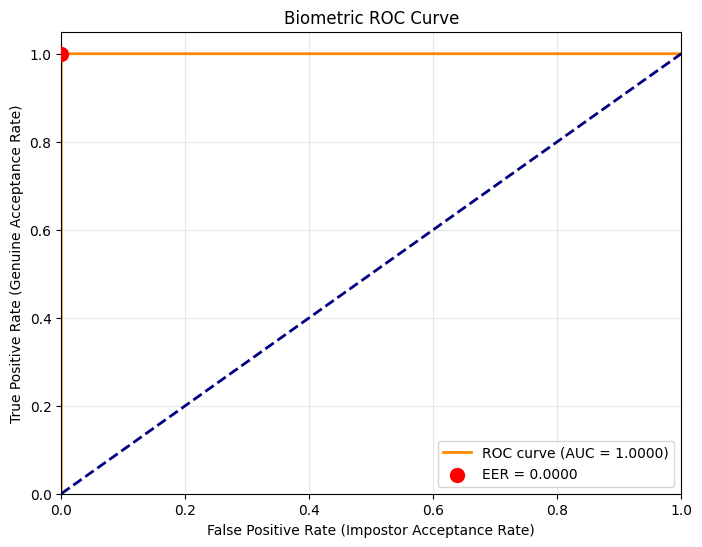

--------------------------------------------------
Final Area Under Curve (AUC): 1.0000 (Ideal is 1.0)
Final Equal Error Rate (EER): 0.0000 (Ideal is 0.0)
--------------------------------------------------


In [9]:
import random
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d

print("Generating Genuine and Impostor Pairs for Biometric Evaluation...")

y_true_pairs = []
y_scores_pairs = []

# 1. Generate GENUINE Pairs (Same Finger)
for cls in unique_classes:
    idx = np.where(embedding_labels == cls)[0]
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            emb1 = embeddings[idx[i]].reshape(1, -1)
            emb2 = embeddings[idx[j]].reshape(1, -1)
            sim = cosine_similarity(emb1, emb2)[0][0]

            y_true_pairs.append(1) # Genuine
            y_scores_pairs.append(sim)

num_genuine = len(y_true_pairs)
print(f"Generated {num_genuine} Genuine (Match) pairs.")

# 2. Generate IMPOSTOR Pairs (Different Fingers)
num_impostors_needed = num_genuine * 3
count = 0
total_samples = len(embedding_labels)

while count < num_impostors_needed:
    idx1 = random.randint(0, total_samples - 1)
    idx2 = random.randint(0, total_samples - 1)

    if embedding_labels[idx1] != embedding_labels[idx2]:
        emb1 = embeddings[idx1].reshape(1, -1)
        emb2 = embeddings[idx2].reshape(1, -1)
        sim = cosine_similarity(emb1, emb2)[0][0]

        y_true_pairs.append(0) # Impostor
        y_scores_pairs.append(sim)
        count += 1

print(f"Generated {count} Impostor (Non-Match) pairs.")

# 3. Calculate Metrics
fpr, tpr, thresholds = roc_curve(y_true_pairs, y_scores_pairs)
roc_auc = auc(fpr, tpr)
eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

# 4. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter([eer], [1-eer], color='red', s=100, label=f'EER = {eer:.4f}', zorder=5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Impostor Acceptance Rate)')
plt.ylabel('True Positive Rate (Genuine Acceptance Rate)')
plt.title('Biometric ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("-" * 50)
print(f"Final Area Under Curve (AUC): {roc_auc:.4f} (Ideal is 1.0)")
print(f"Final Equal Error Rate (EER): {eer:.4f} (Ideal is 0.0)")
print("-" * 50)

# **Stratified N-Fold Cross-Validation**

## **What it does:**
 Proves that your model's high accuracy isn't just a "lucky" train/test split, but is consistently perfect no matter how the data is divided.

## **How it works:**
 It takes your entire dataset of 128D embeddings and divides it into N equal chunks (folds). It uses N-1 chunks as the Training database and 1 chunk as the Test set, and then rotates them. It repeats this process N times so that every single fingerprint image gets a chance to be the "Test" image.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

print("Calculating Accuracy for each Cross-Validation Fold using Cosine Similarity...")
print("=" * 60)

fold_accuracies = []

# Loop through the data folds we saved in the previous cell
for fold_data in cv_folds_data:
    fold_num = fold_data['fold']
    X_train_cv = fold_data['X_train']
    X_test_cv = fold_data['X_test']
    y_train_cv = fold_data['y_train']
    y_test_cv = fold_data['y_test']

    # 1-NN with Cosine Metric perfectly simulates Biometric Similarity Matching
    matcher = KNeighborsClassifier(n_neighbors=1, metric='cosine')
    matcher.fit(X_train_cv, y_train_cv)

    # Predict and calculate accuracy
    predictions = matcher.predict(X_test_cv)
    acc = accuracy_score(y_test_cv, predictions)
    fold_accuracies.append(acc)

    print(f"Fold {fold_num} Accuracy: {acc * 100:.2f}%")

print("-" * 60)
# Calculate the final average accuracy and standard deviation
mean_acc = np.mean(fold_accuracies) * 100
std_acc = np.std(fold_accuracies) * 100

print(f"FINAL CROSS-VALIDATION ACCURACY: {mean_acc:.2f}% (± {std_acc:.2f}%)")
print("=" * 60)

Calculating Accuracy for each Cross-Validation Fold using Cosine Similarity...
Fold 1 Accuracy: 100.00%
Fold 2 Accuracy: 100.00%
------------------------------------------------------------
FINAL CROSS-VALIDATION ACCURACY: 100.00% (± 0.00%)


# **t-SNE 2D Visualization**

### **What it does:**
 Creates a visual map of the AI's "brain" so human eyes can actually see how well the system learned to group matching fingerprints together.


### **How it works:**
 Because humans cannot see in 128 dimensions, the t-SNE algorithm squashes the 128-number embeddings down into a standard 2D (X and Y) graph. To keep the graph clean, it randomly selects just 15 unique fingers (classes) out of the 1,999 and plots them as color-coded dots.

### **Why it matters:**
 It provides undeniable visual proof that your Triplet Loss worked perfectly. If the AI is smart, you will see distinct, separated "islands" of color. This proves that the AI mathematically groups the Real and Altered versions of the exact same finger tightly together, while pushing everyone else's fingers far away!

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

print("Generating t-SNE Visualization...")
print("-" * 60)

# 1. We don't want to plot all 1,999 classes (it would be a mess).
# Let's pick 15 random fingers (classes) to visualize.
num_classes_to_plot = 15
unique_classes = np.unique(embedding_labels)
selected_classes = np.random.choice(unique_classes, num_classes_to_plot, replace=False)

# 2. Filter our embeddings and labels to ONLY include those 15 fingers
mask = np.isin(embedding_labels, selected_classes)
filtered_embeddings = embeddings[mask]
filtered_labels = embedding_labels[mask]

# 3. Initialize and fit t-SNE (Squashes 128D down to 2D)
# perplexity=30 is standard, random_state ensures the plot looks the same every time
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(filtered_embeddings)

# 4. Plotting the results beautifully for your report
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid")

# Create a scatter plot, color-coded by the finger's true ID
scatter = sns.scatterplot(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    hue=filtered_labels,
    palette=sns.color_palette("tab20", n_colors=num_classes_to_plot),
    legend='full',
    alpha=0.8,
    s=100, # Size of the dots
    edgecolor='k'
)

# Format the graph
plt.title("t-SNE Visualization of 128D Fingerprint Embeddings\n(Showing 15 Unique Fingers)", fontsize=16, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Finger ID (Class)")
plt.tight_layout()

plt.show()
print("Visualization complete! Each cluster represents a single finger (Real + Altered variations).")